<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/GasCompressors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gas compression with NeqSim

This tutorial is for process, production, and rotating-equipment engineers who need a
transparent thermodynamic basis for preliminary compressor duties and staging studies.

**Prerequisites:** basic Python, steady-flow energy balances, and familiarity with absolute
pressure and compressor efficiency.

**Learning objectives**

By the end, you will be able to:

- define and validate a single-phase natural-gas feed using SRK;
- connect NeqSim streams, compressors, and an intercooler in a composable flowsheet;
- calculate power, discharge temperature, entropy generation, and energy closure;
- compare the EOS calculation with a constant-property ideal-gas estimate;
- quantify efficiency and intercooling effects;
- optimize interstage pressure for a two-stage train; and
- apply physical and numerical checks before using results for engineering decisions.

In [1]:
import importlib.metadata
import importlib.util
import platform
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )

neqsim_version = importlib.metadata.version("neqsim")
java_version = subprocess.check_output(
    ["java", "-version"],
    stderr=subprocess.STDOUT,
    text=True,
).splitlines()[0]

print(f"NeqSim: {neqsim_version}")
print(f"Python: {platform.python_version()}")
print(f"Java: {java_version}")

NeqSim: 3.16.0
Python: 3.12.13
Java: openjdk version "17.0.19" 2026-04-21


## 1. Engineering question and boundary

The example compresses 1.0 MSm³/day of synthetic natural gas from 35 to 120 bara. It asks
how thermodynamic model choice, compressor efficiency, stage pressure, and intercooling
affect power and discharge temperature.

The boundary is steady-state and adiabatic for each compressor. The intercooler has a fixed
outlet temperature and negligible pressure loss. Mechanical losses, driver efficiency,
compressor maps, surge control, seal systems, fouling, vibration, noise, transient startup,
and vendor tolerances are outside this thermodynamic study.

In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neqsim.process import clearProcess, compressor, cooler, runProcess, stream
from neqsim.thermo import TPflash, fluid


INLET_PRESSURE_BARA = 35.0
FINAL_PRESSURE_BARA = 120.0
INLET_TEMPERATURE_C = 25.0
STANDARD_FLOW_MSM3_DAY = 1.0
BASE_EFFICIENCY = 0.78
INTERCOOLER_TEMPERATURE_C = 30.0
AMBIENT_TEMPERATURE_K = 298.15

## 2. Governing equations

For an adiabatic compressor at steady state, shaft power follows the enthalpy rise:

$$
\dot W=\dot m(h_2-h_1)
$$

$\dot W$ is power in W, $\dot m$ is mass flow in kg/s, and $h$ is specific enthalpy in
J/kg. Isentropic efficiency compares the reversible and actual enthalpy rises:

$$
\eta_s=\frac{h_{2s}-h_1}{h_2-h_1}
$$

For a constant-property ideal gas, the isentropic outlet temperature is:

$$
T_{2s}=T_1\left(\frac{P_2}{P_1}\right)^{(k-1)/k}
$$

$T$ is in K, $P$ is absolute pressure, and $k=C_p/C_v$. NeqSim instead evaluates real-gas
enthalpy and entropy with an equation of state, so the ideal equation is only an independent
screening comparison.

In [3]:
gas_composition = {
    "nitrogen": 0.02,
    "CO2": 0.01,
    "methane": 0.85,
    "ethane": 0.08,
    "propane": 0.04,
}

feed_fluid = fluid("srk")
for component_name, mole_fraction in gas_composition.items():
    feed_fluid.addComponent(component_name, mole_fraction)

feed_fluid.setMixingRule(2)
feed_fluid.setTemperature(INLET_TEMPERATURE_C, "C")
feed_fluid.setPressure(INLET_PRESSURE_BARA, "bara")
feed_fluid.setTotalFlowRate(STANDARD_FLOW_MSM3_DAY, "MSm3/day")
TPflash(feed_fluid)
feed_fluid.initProperties()

composition_sum = sum(gas_composition.values())
phase_count = int(feed_fluid.getNumberOfPhases())
phase_name = str(feed_fluid.getPhase(0).getPhaseTypeName())

print(f"Composition sum: {composition_sum:.6f} mol/mol")
print(f"Phase count: {phase_count}")
print(f"Phase type: {phase_name}")

Composition sum: 1.000000 mol/mol
Phase count: 1
Phase type: gas


## 3. Fluid and model choice

The synthetic mixture is entirely public and deterministic. It represents a lean natural
gas without claiming to reproduce an asset assay. Mole fractions sum to one.

The Soave–Redlich–Kwong equation of state with the classic mixing rule is selected because
it is widely used for hydrocarbon-gas compression. The model must be validated against
measured density, compressibility, caloric data, and phase behaviour for a project fluid.
The feed is flashed before equipment is created; a compressor calculation is accepted only
when its inlet is one gas phase.

In [4]:
feed_density_kg_m3 = float(feed_fluid.getDensity("kg/m3"))
feed_cp_j_kg_k = float(feed_fluid.getCp("J/kgK"))
feed_cv_j_kg_k = float(feed_fluid.getCv("J/kgK"))
feed_gamma = float(feed_fluid.getGamma2())
feed_z = float(feed_fluid.getZ())
feed_mass_flow_kg_s = float(feed_fluid.getFlowRate("kg/sec"))
feed_enthalpy_j_kg = float(feed_fluid.getEnthalpy("J/kg"))
feed_entropy_j_kg_k = float(feed_fluid.getEntropy("J/kgK"))

feed_properties = pd.DataFrame(
    {
        "Quantity": [
            "Density",
            "Compressibility factor",
            "Heat capacity Cp",
            "Heat capacity ratio",
            "Mass flow",
        ],
        "Value": [
            feed_density_kg_m3,
            feed_z,
            feed_cp_j_kg_k,
            feed_gamma,
            feed_mass_flow_kg_s,
        ],
        "SI unit": ["kg/m³", "-", "J/(kg·K)", "-", "kg/s"],
    }
)
feed_properties

                 Quantity        Value   SI unit
0                 Density    28.880584     kg/m³
1  Compressibility factor     0.920869         -
2        Heat capacity Cp  2321.485029  J/(kg·K)
3     Heat capacity ratio     1.235242         -
4               Mass flow     9.205678      kg/s

## 4. NeqSim process representation

NeqSim separates thermodynamics from equipment connectivity:

1. the fluid stores composition, model, pressure, temperature, and flow basis;
2. a `Stream` exposes that state to the flowsheet;
3. a `Compressor` imposes discharge pressure and efficiency; and
4. `runProcess()` solves the units in order and updates named outlet streams.

Keeping the feed and discharge streams available makes the example reusable inside a larger
separator, pipeline, cooling, or export-gas simulation.

In [5]:
clearProcess()

feed_stream = stream("compressor feed", feed_fluid)
single_stage_compressor = compressor(
    "single-stage compressor",
    feed_stream,
    pres=FINAL_PRESSURE_BARA,
)
single_stage_compressor.setIsentropicEfficiency(BASE_EFFICIENCY)

runProcess()
single_stage_outlet = single_stage_compressor.getOutletStream()

## 5. Base single-stage result

Compression raises both pressure and temperature. Shaft power must be positive, mass flow
must be conserved, and the outlet must remain finite and single phase. Entropy rises because
the specified efficiency is below one. The resulting exergy destruction gives a useful
thermodynamic measure of irreversibility, but it does not include the motor or driver.

In [6]:
single_power_mw = float(single_stage_compressor.getPower("MW"))
single_outlet_temperature_c = float(single_stage_outlet.getTemperature("C"))
single_outlet_pressure_bara = float(single_stage_outlet.getPressure("bara"))
single_outlet_mass_flow_kg_s = float(single_stage_outlet.getFlowRate("kg/sec"))
single_outlet_enthalpy_j_kg = float(
    single_stage_outlet.getFluid().getEnthalpy("J/kg")
)
single_outlet_entropy_j_kg_k = float(
    single_stage_outlet.getFluid().getEntropy("J/kgK")
)

single_enthalpy_power_mw = (
    feed_mass_flow_kg_s
    * (single_outlet_enthalpy_j_kg - feed_enthalpy_j_kg)
    / 1.0e6
)
single_energy_residual_w = (
    single_power_mw - single_enthalpy_power_mw
) * 1.0e6
single_mass_residual_kg_s = single_outlet_mass_flow_kg_s - feed_mass_flow_kg_s
specific_entropy_generation_j_kg_k = (
    single_outlet_entropy_j_kg_k - feed_entropy_j_kg_k
)
exergy_destruction_mw = (
    AMBIENT_TEMPERATURE_K
    * feed_mass_flow_kg_s
    * specific_entropy_generation_j_kg_k
    / 1.0e6
)

single_stage_results = pd.DataFrame(
    {
        "Quantity": [
            "Discharge pressure",
            "Discharge temperature",
            "Shaft power",
            "Mass residual",
            "Energy residual",
            "Specific entropy generation",
            "Exergy destruction",
        ],
        "Value": [
            single_outlet_pressure_bara,
            single_outlet_temperature_c,
            single_power_mw,
            single_mass_residual_kg_s,
            single_energy_residual_w,
            specific_entropy_generation_j_kg_k,
            exergy_destruction_mw,
        ],
        "Unit": ["bara", "°C", "MW", "kg/s", "W", "J/(kg·K)", "MW"],
    }
)
single_stage_results

                      Quantity         Value      Unit
0           Discharge pressure  1.200000e+02      bara
1        Discharge temperature  1.374428e+02        °C
2                  Shaft power  2.060508e+00        MW
3                Mass residual  0.000000e+00      kg/s
4              Energy residual -4.440892e-10         W
5  Specific entropy generation  1.225973e+02  J/(kg·K)
6           Exergy destruction  3.364894e-01        MW

## 6. Independent ideal-gas comparison

The shortcut freezes inlet $C_p$, $k$, and compressibility effects over the entire pressure
rise. It is useful as an order-of-magnitude and limiting-behaviour check. It is not expected
to reproduce SRK exactly because real-gas heat capacity, enthalpy departure, and
compressibility change during compression.

In [7]:
inlet_temperature_k = INLET_TEMPERATURE_C + 273.15
compression_ratio = FINAL_PRESSURE_BARA / INLET_PRESSURE_BARA
ideal_isentropic_temperature_k = inlet_temperature_k * compression_ratio ** (
    (feed_gamma - 1.0) / feed_gamma
)
ideal_actual_temperature_k = inlet_temperature_k + (
    ideal_isentropic_temperature_k - inlet_temperature_k
) / BASE_EFFICIENCY
ideal_power_mw = (
    feed_mass_flow_kg_s
    * feed_cp_j_kg_k
    * (ideal_actual_temperature_k - inlet_temperature_k)
    / 1.0e6
)
ideal_outlet_temperature_c = ideal_actual_temperature_k - 273.15
power_difference_percent = 100.0 * (
    ideal_power_mw - single_power_mw
) / single_power_mw
temperature_difference_c = (
    ideal_outlet_temperature_c - single_outlet_temperature_c
)

ideal_comparison = pd.DataFrame(
    {
        "Method": ["NeqSim SRK", "Constant-property ideal gas"],
        "Power [MW]": [single_power_mw, ideal_power_mw],
        "Discharge temperature [°C]": [
            single_outlet_temperature_c,
            ideal_outlet_temperature_c,
        ],
    }
)
ideal_comparison

                        Method  Power [MW]  Discharge temperature [°C]
0                   NeqSim SRK    2.060508                  137.442793
1  Constant-property ideal gas    2.160408                  126.091369

## 7. Reusable single-stage case

Each sensitivity case rebuilds the fluid, stream, and compressor from the validated base
definition. This avoids hidden state and makes pressure, efficiency, phase, and energy
checks available for every scenario.

In [8]:
def run_single_stage_case(
    efficiency: float,
    discharge_pressure_bara: float,
) -> dict[str, float]:
    clearProcess()

    case_fluid = feed_fluid.clone()
    case_fluid.setTemperature(INLET_TEMPERATURE_C, "C")
    case_fluid.setPressure(INLET_PRESSURE_BARA, "bara")
    TPflash(case_fluid)

    case_feed = stream("case feed", case_fluid)
    case_compressor = compressor(
        "case compressor",
        case_feed,
        pres=discharge_pressure_bara,
    )
    case_compressor.setIsentropicEfficiency(efficiency)
    runProcess()

    case_outlet = case_compressor.getOutletStream()
    inlet_h_j_kg = float(case_feed.getFluid().getEnthalpy("J/kg"))
    outlet_h_j_kg = float(case_outlet.getFluid().getEnthalpy("J/kg"))
    mass_flow_kg_s = float(case_feed.getFlowRate("kg/sec"))
    power_mw = float(case_compressor.getPower("MW"))
    enthalpy_power_mw = (
        mass_flow_kg_s * (outlet_h_j_kg - inlet_h_j_kg) / 1.0e6
    )

    return {
        "efficiency [-]": efficiency,
        "discharge pressure [bara]": discharge_pressure_bara,
        "power [MW]": power_mw,
        "discharge temperature [°C]": float(case_outlet.getTemperature("C")),
        "energy residual [W]": (power_mw - enthalpy_power_mw) * 1.0e6,
        "phase count [-]": float(case_outlet.getFluid().getNumberOfPhases()),
    }

## 8. Efficiency sensitivity

At fixed flow and pressure ratio, poorer efficiency increases shaft power and discharge
temperature. The 65–85% range is illustrative; a project must use a qualified compressor
map at the expected speed, inlet state, molecular weight, and actual volume flow.

   efficiency [-]  ...  phase count [-]
0            0.65  ...              1.0
1            0.70  ...              1.0
2            0.75  ...              1.0
3            0.78  ...              1.0
4            0.80  ...              1.0
5            0.85  ...              1.0

[6 rows x 6 columns]

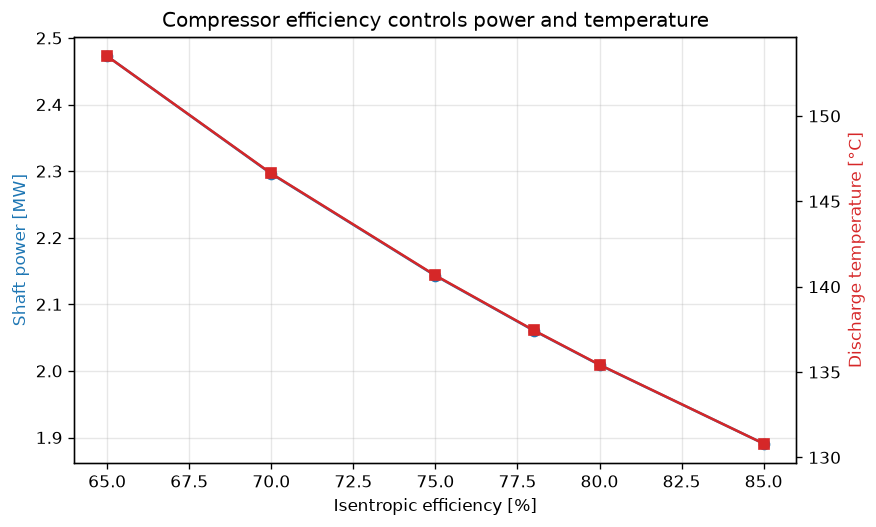

In [9]:
efficiency_values = np.array([0.65, 0.70, 0.75, 0.78, 0.80, 0.85])
efficiency_results = pd.DataFrame(
    [
        run_single_stage_case(
            efficiency=value,
            discharge_pressure_bara=FINAL_PRESSURE_BARA,
        )
        for value in efficiency_values
    ]
)

fig, efficiency_power_axis = plt.subplots(figsize=(7.4, 4.5))
efficiency_temperature_axis = efficiency_power_axis.twinx()
efficiency_power_axis.plot(
    100.0 * efficiency_results["efficiency [-]"],
    efficiency_results["power [MW]"],
    marker="o",
    color="tab:blue",
    label="Shaft power",
)
efficiency_temperature_axis.plot(
    100.0 * efficiency_results["efficiency [-]"],
    efficiency_results["discharge temperature [°C]"],
    marker="s",
    color="tab:red",
    label="Discharge temperature",
)
efficiency_power_axis.set_xlabel("Isentropic efficiency [%]")
efficiency_power_axis.set_ylabel("Shaft power [MW]", color="tab:blue")
efficiency_temperature_axis.set_ylabel(
    "Discharge temperature [°C]",
    color="tab:red",
)
efficiency_power_axis.set_title("Compressor efficiency controls power and temperature")
efficiency_power_axis.grid(alpha=0.3)
fig.tight_layout()
plt.show()

efficiency_results

## 9. Why stage compression?

For an ideal gas with perfect intercooling and equal stage efficiencies, minimum work occurs
near equal pressure ratios. For two stages, the geometric estimate is:

$$
P_{int}=\sqrt{P_1P_3}
$$

$P_{int}$, $P_1$, and $P_3$ are absolute pressures in the same unit. Real-gas properties,
unequal efficiencies, cooler approach, pressure losses, and compressor maps can shift the
optimum, so the candidate pressure is evaluated with NeqSim.

In [10]:
geometric_interstage_pressure_bara = math.sqrt(
    INLET_PRESSURE_BARA * FINAL_PRESSURE_BARA
)

clearProcess()

two_stage_fluid = feed_fluid.clone()
two_stage_fluid.setTemperature(INLET_TEMPERATURE_C, "C")
two_stage_fluid.setPressure(INLET_PRESSURE_BARA, "bara")
TPflash(two_stage_fluid)

two_stage_feed = stream("two-stage feed", two_stage_fluid)
first_stage = compressor(
    "first-stage compressor",
    two_stage_feed,
    pres=geometric_interstage_pressure_bara,
)
first_stage.setIsentropicEfficiency(BASE_EFFICIENCY)

intercooler = cooler("intercooler", first_stage.getOutletStream())
intercooler.setOutTemperature(INTERCOOLER_TEMPERATURE_C + 273.15)

second_stage = compressor(
    "second-stage compressor",
    intercooler.getOutletStream(),
    pres=FINAL_PRESSURE_BARA,
)
second_stage.setIsentropicEfficiency(BASE_EFFICIENCY)

runProcess()
two_stage_outlet = second_stage.getOutletStream()

## 10. Two-stage balances and temperatures

Each compressor must close its enthalpy-power balance. The intercooler duty is negative
because heat leaves the process stream. The complete train balance includes both compressor
powers and the cooler duty. Mass flow remains unchanged through all units.

In [11]:
first_stage_power_mw = float(first_stage.getPower("MW"))
second_stage_power_mw = float(second_stage.getPower("MW"))
two_stage_power_mw = first_stage_power_mw + second_stage_power_mw
intercooler_duty_mw = float(intercooler.getDuty()) / 1.0e6
first_stage_temperature_c = float(first_stage.getOutletStream().getTemperature("C"))
second_stage_temperature_c = float(two_stage_outlet.getTemperature("C"))
two_stage_mass_residual_kg_s = (
    two_stage_outlet.getFlowRate("kg/sec")
    - two_stage_feed.getFlowRate("kg/sec")
)

two_stage_inlet_h_j_kg = float(two_stage_feed.getFluid().getEnthalpy("J/kg"))
two_stage_outlet_h_j_kg = float(
    two_stage_outlet.getFluid().getEnthalpy("J/kg")
)
two_stage_enthalpy_change_mw = (
    feed_mass_flow_kg_s
    * (two_stage_outlet_h_j_kg - two_stage_inlet_h_j_kg)
    / 1.0e6
)
two_stage_energy_residual_w = (
    first_stage_power_mw
    + intercooler_duty_mw
    + second_stage_power_mw
    - two_stage_enthalpy_change_mw
) * 1.0e6

two_stage_results = pd.DataFrame(
    {
        "Quantity": [
            "Interstage pressure",
            "First-stage power",
            "Second-stage power",
            "Total compressor power",
            "Intercooler duty",
            "First-stage discharge temperature",
            "Second-stage discharge temperature",
            "Overall energy residual",
        ],
        "Value": [
            geometric_interstage_pressure_bara,
            first_stage_power_mw,
            second_stage_power_mw,
            two_stage_power_mw,
            intercooler_duty_mw,
            first_stage_temperature_c,
            second_stage_temperature_c,
            two_stage_energy_residual_w,
        ],
        "Unit": ["bara", "MW", "MW", "MW", "MW", "°C", "°C", "W"],
    }
)
two_stage_results

                             Quantity         Value  Unit
0                 Interstage pressure  6.480741e+01  bara
1                   First-stage power  9.506203e-01    MW
2                  Second-stage power  9.273999e-01    MW
3              Total compressor power  1.878020e+00    MW
4                    Intercooler duty -1.162798e+00    MW
5   First-stage discharge temperature  7.942289e+01    °C
6  Second-stage discharge temperature  8.490963e+01    °C
7             Overall energy residual -2.220446e-10     W

## 11. Quantify the benefit of intercooling

Cooling between stages reduces the specific volume and the work required by the second
stage. It also lowers the maximum train discharge temperature. This benefit must later be
balanced against cooler cost, pressure loss, plot space, cooling-medium temperature, and
liquid dropout risk.

In [12]:
power_saving_percent = 100.0 * (
    single_power_mw - two_stage_power_mw
) / single_power_mw
maximum_single_temperature_c = single_outlet_temperature_c
maximum_two_stage_temperature_c = max(
    first_stage_temperature_c,
    second_stage_temperature_c,
)
temperature_reduction_c = (
    maximum_single_temperature_c - maximum_two_stage_temperature_c
)

configuration_comparison = pd.DataFrame(
    {
        "Configuration": ["Single stage", "Two stages with intercooling"],
        "Compressor power [MW]": [single_power_mw, two_stage_power_mw],
        "Maximum discharge temperature [°C]": [
            maximum_single_temperature_c,
            maximum_two_stage_temperature_c,
        ],
    }
)
configuration_comparison

                  Configuration  ...  Maximum discharge temperature [°C]
0                  Single stage  ...                          137.442793
1  Two stages with intercooling  ...                           84.909626

[2 rows x 3 columns]

## 12. Reusable two-stage case

The function makes interstage pressure and intercooler temperature explicit design
variables. It returns stage powers, temperatures, phase count, and a complete train energy
residual. Rebuilding each case keeps the study deterministic and independent of loop order.

In [13]:
def run_two_stage_case(
    interstage_pressure_bara: float,
    intercooler_temperature_c: float,
) -> dict[str, float]:
    clearProcess()

    case_fluid = feed_fluid.clone()
    case_fluid.setTemperature(INLET_TEMPERATURE_C, "C")
    case_fluid.setPressure(INLET_PRESSURE_BARA, "bara")
    TPflash(case_fluid)

    case_feed = stream("staged case feed", case_fluid)
    case_first_stage = compressor(
        "staged case first compressor",
        case_feed,
        pres=interstage_pressure_bara,
    )
    case_first_stage.setIsentropicEfficiency(BASE_EFFICIENCY)

    case_cooler = cooler(
        "staged case intercooler",
        case_first_stage.getOutletStream(),
    )
    case_cooler.setOutTemperature(intercooler_temperature_c + 273.15)

    case_second_stage = compressor(
        "staged case second compressor",
        case_cooler.getOutletStream(),
        pres=FINAL_PRESSURE_BARA,
    )
    case_second_stage.setIsentropicEfficiency(BASE_EFFICIENCY)
    runProcess()

    case_outlet = case_second_stage.getOutletStream()
    first_power_mw = float(case_first_stage.getPower("MW"))
    second_power_mw = float(case_second_stage.getPower("MW"))
    cooler_duty_mw = float(case_cooler.getDuty()) / 1.0e6
    inlet_h_j_kg = float(case_feed.getFluid().getEnthalpy("J/kg"))
    outlet_h_j_kg = float(case_outlet.getFluid().getEnthalpy("J/kg"))
    enthalpy_change_mw = (
        feed_mass_flow_kg_s * (outlet_h_j_kg - inlet_h_j_kg) / 1.0e6
    )

    return {
        "interstage pressure [bara]": interstage_pressure_bara,
        "intercooler temperature [°C]": intercooler_temperature_c,
        "first-stage power [MW]": first_power_mw,
        "second-stage power [MW]": second_power_mw,
        "total power [MW]": first_power_mw + second_power_mw,
        "first-stage temperature [°C]": float(
            case_first_stage.getOutletStream().getTemperature("C")
        ),
        "second-stage temperature [°C]": float(case_outlet.getTemperature("C")),
        "energy residual [W]": (
            first_power_mw + cooler_duty_mw + second_power_mw - enthalpy_change_mw
        )
        * 1.0e6,
        "phase count [-]": float(case_outlet.getFluid().getNumberOfPhases()),
    }

## 13. Interstage-pressure optimization

The grid spans 50–85 bara and holds stage efficiencies and cooler temperature fixed. Total
power should form a shallow minimum. Stage powers cross near the optimum, but equal power is
not itself a universal design requirement. The screened optimum must later be reconciled
with available compressor maps, speed, head, casing limits, and pressure losses.

Geometric estimate: 64.807 bara
NeqSim grid optimum: 69.000 bara
Minimum two-stage power: 1.875959 MW


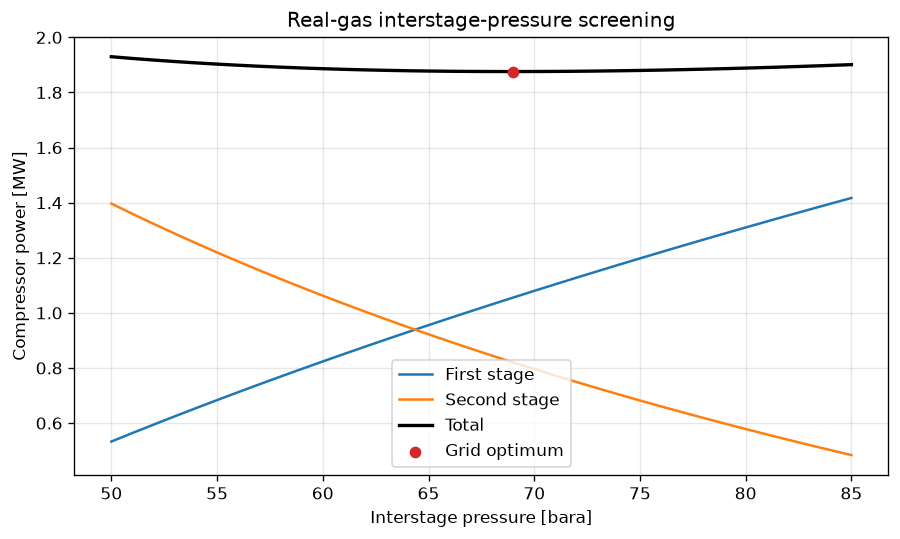

In [14]:
interstage_pressures_bara = np.arange(50.0, 86.0, 1.0)
interstage_results = pd.DataFrame(
    [
        run_two_stage_case(
            interstage_pressure_bara=value,
            intercooler_temperature_c=INTERCOOLER_TEMPERATURE_C,
        )
        for value in interstage_pressures_bara
    ]
)

minimum_power_index = int(interstage_results["total power [MW]"].idxmin())
optimum_interstage_pressure_bara = float(
    interstage_results.loc[minimum_power_index, "interstage pressure [bara]"]
)
minimum_two_stage_power_mw = float(
    interstage_results.loc[minimum_power_index, "total power [MW]"]
)

fig, pressure_axis = plt.subplots(figsize=(7.6, 4.6))
pressure_axis.plot(
    interstage_results["interstage pressure [bara]"],
    interstage_results["first-stage power [MW]"],
    label="First stage",
    color="tab:blue",
)
pressure_axis.plot(
    interstage_results["interstage pressure [bara]"],
    interstage_results["second-stage power [MW]"],
    label="Second stage",
    color="tab:orange",
)
pressure_axis.plot(
    interstage_results["interstage pressure [bara]"],
    interstage_results["total power [MW]"],
    label="Total",
    color="black",
    linewidth=2.0,
)
pressure_axis.scatter(
    [optimum_interstage_pressure_bara],
    [minimum_two_stage_power_mw],
    color="tab:red",
    label="Grid optimum",
    zorder=5,
)
pressure_axis.set_xlabel("Interstage pressure [bara]")
pressure_axis.set_ylabel("Compressor power [MW]")
pressure_axis.set_title("Real-gas interstage-pressure screening")
pressure_axis.grid(alpha=0.3)
pressure_axis.legend()
fig.tight_layout()
plt.show()

print(f"Geometric estimate: {geometric_interstage_pressure_bara:.3f} bara")
print(f"NeqSim grid optimum: {optimum_interstage_pressure_bara:.3f} bara")
print(f"Minimum two-stage power: {minimum_two_stage_power_mw:.6f} MW")

## 14. Intercooler-temperature sensitivity

A colder interstage gas generally reduces second-stage work. The sweep from 20 to 50°C is
chosen to show the trend, not to define an achievable utility approach. Before selecting a
temperature, check ambient conditions, cooler approach, hydrate or condensation margins,
materials, pressure drop, and separator requirements.

   interstage pressure [bara]  ...  maximum stage temperature [°C]
0                        69.0  ...                       85.174076
1                        69.0  ...                       85.174076
2                        69.0  ...                       85.174076
3                        69.0  ...                       85.174076
4                        69.0  ...                       90.078606
5                        69.0  ...                      101.013105

[6 rows x 10 columns]

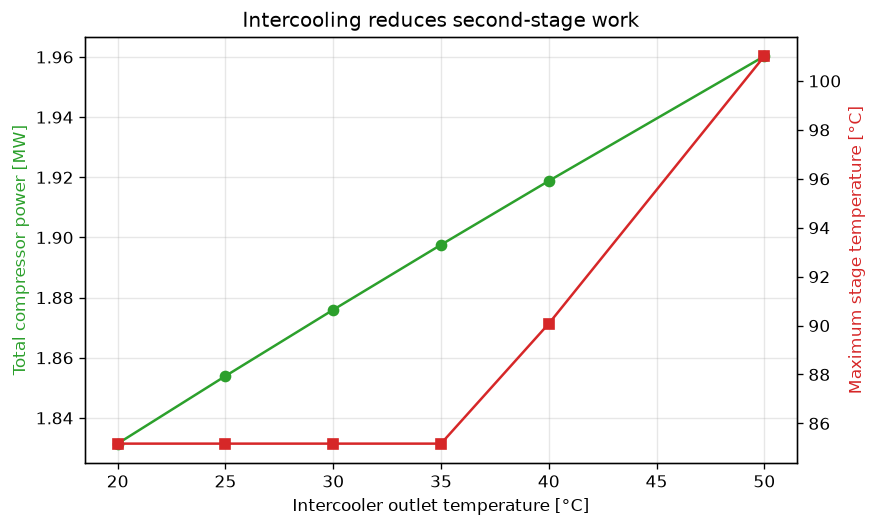

In [15]:
intercooler_temperatures_c = np.array([20.0, 25.0, 30.0, 35.0, 40.0, 50.0])
intercooler_results = pd.DataFrame(
    [
        run_two_stage_case(
            interstage_pressure_bara=optimum_interstage_pressure_bara,
            intercooler_temperature_c=value,
        )
        for value in intercooler_temperatures_c
    ]
)
intercooler_results["maximum stage temperature [°C]"] = intercooler_results[
    ["first-stage temperature [°C]", "second-stage temperature [°C]"]
].max(axis=1)

fig, cooler_power_axis = plt.subplots(figsize=(7.4, 4.5))
cooler_temperature_axis = cooler_power_axis.twinx()
cooler_power_axis.plot(
    intercooler_results["intercooler temperature [°C]"],
    intercooler_results["total power [MW]"],
    marker="o",
    color="tab:green",
)
cooler_temperature_axis.plot(
    intercooler_results["intercooler temperature [°C]"],
    intercooler_results["maximum stage temperature [°C]"],
    marker="s",
    color="tab:red",
)
cooler_power_axis.set_xlabel("Intercooler outlet temperature [°C]")
cooler_power_axis.set_ylabel("Total compressor power [MW]", color="tab:green")
cooler_temperature_axis.set_ylabel(
    "Maximum stage temperature [°C]",
    color="tab:red",
)
cooler_power_axis.set_title("Intercooling reduces second-stage work")
cooler_power_axis.grid(alpha=0.3)
fig.tight_layout()
plt.show()

intercooler_results

## 15. Verification strategy

The checks cover composition, phase state, finite results, pressure ordering, mass and energy
closure, positive entropy generation, ideal-gas agreement, expected efficiency trends,
intercooling benefit, a bounded interstage optimum, temperature sensitivity, and repeated
scenario convergence. These numerical tolerances verify the model implementation; they are
not equipment acceptance tolerances.

In [16]:
maximum_scenario_energy_residual_w = max(
    efficiency_results["energy residual [W]"].abs().max(),
    interstage_results["energy residual [W]"].abs().max(),
    intercooler_results["energy residual [W]"].abs().max(),
)

engineering_checks = {
    "current NeqSim release recorded": neqsim_version == "3.16.0",
    "composition closes": abs(composition_sum - 1.0) < 1.0e-12,
    "single gas feed": phase_count == 1 and phase_name == "gas",
    "single gas discharge": single_stage_outlet.getFluid().getNumberOfPhases() == 1,
    "pressure target met": abs(single_outlet_pressure_bara - FINAL_PRESSURE_BARA) < 1.0e-9,
    "finite positive single-stage power": math.isfinite(single_power_mw)
    and single_power_mw > 0.0,
    "single-stage mass balance closes": abs(single_mass_residual_kg_s) < 1.0e-10,
    "single-stage energy balance closes": abs(single_energy_residual_w) < 1.0e-5,
    "entropy generation positive": specific_entropy_generation_j_kg_k > 0.0,
    "ideal-gas power agrees within ten percent": abs(power_difference_percent) < 10.0,
    "ideal-gas temperature agrees within fifteen degrees": abs(
        temperature_difference_c
    ) < 15.0,
    "higher efficiency lowers power": np.all(
        np.diff(efficiency_results["power [MW]"]) < 0.0
    ),
    "higher efficiency lowers temperature": np.all(
        np.diff(efficiency_results["discharge temperature [°C]"]) < 0.0
    ),
    "two-stage mass balance closes": abs(two_stage_mass_residual_kg_s) < 1.0e-10,
    "two-stage energy balance closes": abs(two_stage_energy_residual_w) < 1.0e-5,
    "intercooling reduces compressor power": power_saving_percent > 5.0,
    "intercooling reduces maximum temperature": temperature_reduction_c > 30.0,
    "optimum within screened range": 50.0 < optimum_interstage_pressure_bara < 85.0,
    "optimum close to geometric estimate": abs(
        optimum_interstage_pressure_bara - geometric_interstage_pressure_bara
    ) < 10.0,
    "warmer intercooling increases power": np.all(
        np.diff(intercooler_results["total power [MW]"]) > 0.0
    ),
    "all scenario energy balances close": maximum_scenario_energy_residual_w < 1.0e-5,
    "all scenario outlets remain one phase": (
        efficiency_results["phase count [-]"].eq(1.0).all()
        and interstage_results["phase count [-]"].eq(1.0).all()
        and intercooler_results["phase count [-]"].eq(1.0).all()
    ),
}

failed_checks = [
    name for name, passed in engineering_checks.items() if not bool(passed)
]
assert not failed_checks, f"Failed engineering checks: {failed_checks}"

print(f"All {len(engineering_checks)} engineering checks passed.")

All 22 engineering checks passed.


## 16. Troubleshooting

- **The inlet is multiphase:** add a scrubber or revise temperature and pressure before the
  compressor. Do not interpret a dry-gas compressor result for liquid carryover.
- **Power is negative or pressure does not rise:** verify compressor outlet pressure, unit
  order, and use the current `getPower("MW")` API; an incompatible map can also create an
  invalid operating point.
- **Discharge temperature is too high:** consider more stages, intercooling, lower pressure
  ratio per stage, or improved efficiency, then check material and seal limits.
- **A staged case fails:** use realistic pressure guesses strictly between suction and final
  pressure, and ensure the intercooler does not create a condensed phase without a scrubber.
- **Map and surge studies:** use corrected flow, corrected speed, head, efficiency, surge,
  and stonewall data from a qualified vendor. Do not invent a map from this duty-only model.

In [17]:
diagnostic_summary = pd.DataFrame(
    {
        "Diagnostic": [
            "Feed phase",
            "Single-stage power",
            "Single-stage discharge temperature",
            "Ideal-gas power difference",
            "Two-stage power",
            "Power saving from staging",
            "NeqSim optimum interstage pressure",
            "Maximum energy residual",
        ],
        "Result": [
            phase_name,
            f"{single_power_mw:.6f} MW",
            f"{single_outlet_temperature_c:.3f} °C",
            f"{power_difference_percent:.3f} %",
            f"{two_stage_power_mw:.6f} MW",
            f"{power_saving_percent:.3f} %",
            f"{optimum_interstage_pressure_bara:.3f} bara",
            f"{maximum_scenario_energy_residual_w:.3e} W",
        ],
    }
)
diagnostic_summary

                           Diagnostic       Result
0                          Feed phase          gas
1                  Single-stage power  2.060508 MW
2  Single-stage discharge temperature   137.443 °C
3          Ideal-gas power difference      4.848 %
4                     Two-stage power  1.878020 MW
5           Power saving from staging      8.856 %
6  NeqSim optimum interstage pressure  69.000 bara
7             Maximum energy residual  4.441e-10 W

## 17. Limitations and applicability

This notebook supports thermodynamic duty estimation and preliminary staging studies for a
single-phase gas. It does not qualify a centrifugal compressor. A project design also needs
vendor maps, corrected coordinates, surge and choke margins, settle-out and restart cases,
driver and gearbox efficiencies, recycle and anti-surge dynamics, cooler and scrubber
pressure losses, hydrate and liquid-dropout checks, mechanical design, noise, vibration,
materials, seals, availability, and control or safeguarding studies.

The fixed efficiencies are illustrative. SRK results should be compared with measured or
trusted reference properties over the entire operating envelope, especially for high CO₂,
hydrogen, water-rich, or dense-phase service.

## 18. Summary, exercises, and references

NeqSim calculated a real-gas single-stage duty, closed the enthalpy and mass balances, and
agreed with a constant-property ideal-gas estimate at screening accuracy. Two-stage
compression with intercooling reduced power and maximum temperature. A deterministic sweep
located the real-gas interstage-pressure minimum and showed the effect of cooler outlet
temperature.

**Exercises**

1. Replace the synthetic feed with a measured gas and compare SRK, PR, and GERG-2008.
2. Add realistic cooler and scrubber pressure drops and repeat the pressure optimization.
3. Add a third stage and compare equal-ratio and optimized stage pressures.
4. Import a public vendor map and calculate surge and stonewall margins without extrapolating
   beyond its qualified range.

**Current NeqSim references**

- [Process simulation documentation](https://equinor.github.io/neqsim/process/README.html)
- [Process recipes for compressors and intercooling](https://equinor.github.io/neqsim/cookbook/process-recipes.html)
- [Thermodynamic model selection](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html)
- [Getting started and equipment overview](https://equinor.github.io/neqsim/wiki/getting_started.html)